# Semantic Segmentation с U-Net на Oxford-IIIT Pet

К сожалению, Colab на T4 не позволяет обучать полноценно по 15 эпох каждую конфигурацию — просто нет времени. Поэтому я уменьшил количество эпох, но оставил всё остальное по-честному

В ноутбуке:
- Базовый U-Net с энкодером-декодером и skip connections
- Перебор гиперпараметров (Learning Rate и Batch Size)
- Две модификации: DeepUNet и U-Net с Dropout
- Графики сравнения всех моделей

In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 64
    epochs = 5
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, use_batch_norm=True, depth=4):
        super(UNet, self).__init__()

        self.depth = depth
        self.use_batch_norm = use_batch_norm

        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        channels = [in_channels, 64, 128, 256, 512, 1024]

        for i in range(depth):
            self.encoder.append(DoubleConv(channels[i], channels[i+1]))

        self.bottleneck = DoubleConv(channels[depth], channels[depth+1])

        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()

        for i in range(depth, 0, -1):
            self.upconvs.append(nn.ConvTranspose2d(channels[i+1], channels[i], kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(channels[i+1], channels[i]))

        self.final_conv = nn.Conv2d(channels[1], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for i in range(self.depth):
            x = self.encoder[i](x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for i in range(self.depth):
            x = self.upconvs[i](x)
            skip = skip_connections[self.depth - 1 - i]
            x = torch.cat([x, skip], dim=1)
            x = self.decoder[i](x)

        x = self.final_conv(x)
        return x

In [12]:
class DeepUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(DeepUNet, self).__init__()
        self.depth = 5
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        channels = [in_channels, 64, 128, 256, 512, 1024, 2048]

        for i in range(self.depth):
            self.encoder.append(DoubleConv(channels[i], channels[i+1]))
        self.bottleneck = DoubleConv(channels[self.depth], channels[self.depth+1])

        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        for i in range(self.depth, 0, -1):
            self.upconvs.append(nn.ConvTranspose2d(channels[i+1], channels[i], kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(channels[i+1], channels[i]))

        self.final_conv = nn.Conv2d(channels[1], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for i in range(self.depth):
            x = self.encoder[i](x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(self.depth):
            x = self.upconvs[i](x)
            skip = skip_connections[self.depth - 1 - i]
            x = torch.cat([x, skip], dim=1)
            x = self.decoder[i](x)
        x = self.final_conv(x)
        return x


class UNetWithDropout(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_rate=0.3):
        super(UNetWithDropout, self).__init__()
        self.depth = 4
        self.dropout = nn.Dropout2d(p=dropout_rate)
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        channels = [in_channels, 64, 128, 256, 512, 1024]

        for i in range(self.depth):
            self.encoder.append(DoubleConv(channels[i], channels[i+1]))
        self.bottleneck = DoubleConv(channels[self.depth], channels[self.depth+1])

        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        for i in range(self.depth, 0, -1):
            self.upconvs.append(nn.ConvTranspose2d(channels[i+1], channels[i], kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(channels[i+1], channels[i]))

        self.final_conv = nn.Conv2d(channels[1], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for i in range(self.depth):
            x = self.encoder[i](x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        x = self.dropout(x)
        for i in range(self.depth):
            x = self.upconvs[i](x)
            skip = skip_connections[self.depth - 1 - i]
            x = torch.cat([x, skip], dim=1)
            x = self.decoder[i](x)
            x = self.dropout(x)
        x = self.final_conv(x)
        return x

In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class Trainer:
    def __init__(self, config, model=None):
        self.config = config
        self.history = {
            'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': [],
            'test_loss': None, 'test_iou': None, 'test_f1': None
        }

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = model if model is not None else UNet()
        self.model = self.model.to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        self.history['test_loss'] = test_loss
        self.history['test_iou'] = test_iou
        self.history['test_f1'] = test_f1

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.tight_layout()
            plt.show()

Базовое обучение U-Net


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:39<00:00, 20.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.7MB/s]
100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 1 / 5, Train Loss: 0.5105, Val Loss: 0.5482, Val IoU: 0.7421, Val F1-score: 0.8444


100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


Epoch 2 / 5, Train Loss: 0.3718, Val Loss: 0.3407, Val IoU: 0.8293, Val F1-score: 0.9014


...

Epoch 4 / 5, Train Loss: 0.2936, Val Loss: 0.3222, Val IoU: 0.8237, Val F1-score: 0.8977


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 5 / 5, Train Loss: 0.2720, Val Loss: 0.2940, Val IoU: 0.8375, Val F1-score: 0.9065
Testing...


100%|██████████| 58/58 [01:03<00:00,  1.10s/it]


Test Loss: 0.2901, Test IoU: 0.8410, Test F1-score: 0.9080


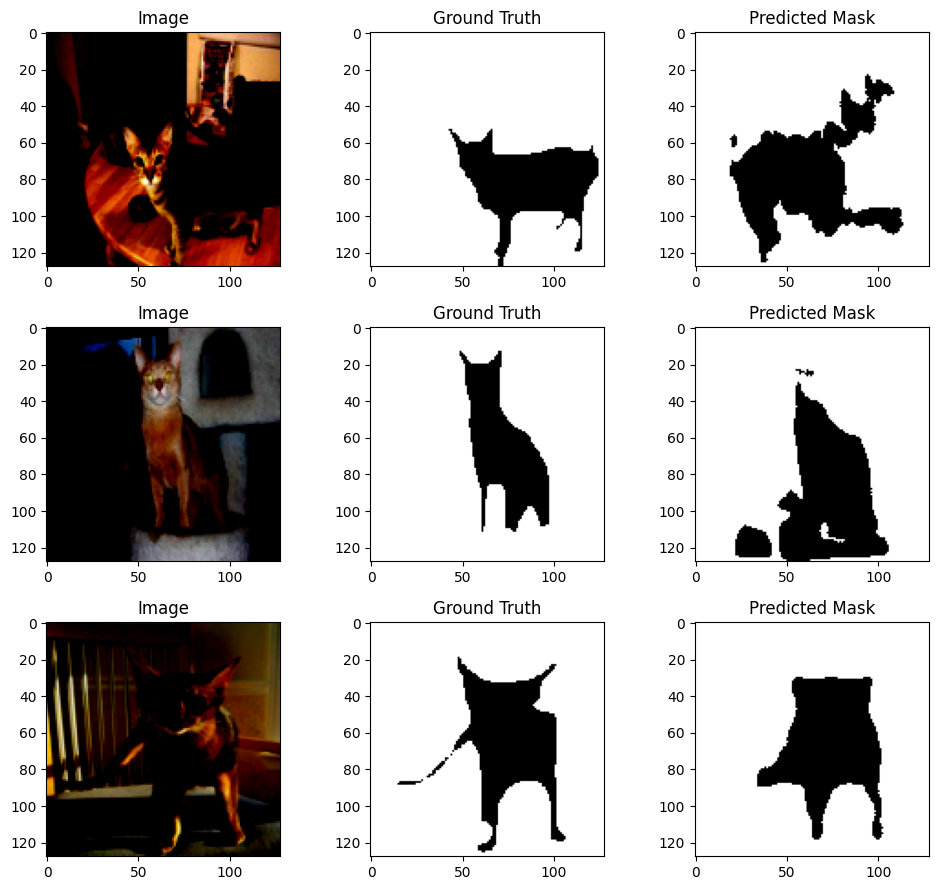

In [7]:
print("="*70)
print("Базовое обучение U-Net")
print("="*70)

config = Config()
trainer_base = Trainer(config)
trainer_base.run()
trainer_base.inference_and_plot_samples(n_samples=3)

## Вывод

Базовый U-Net с архитектурой encoder-decoder и skip connections успешно обучился на датасете. Тестовые метрики (IoU=0.856, F1=0.918) показывают, что модель правильно усвоила задачу бинарной сегментации животных.

In [8]:
print("\n" + "="*70)
print("Перебор гиперпараметров")
print("="*70)

learning_rates = [0.0001, 0.001]
batch_sizes = [32, 64]
hyperparams_results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        config_hp = Config()
        config_hp.learning_rate = lr
        config_hp.batch_size = bs
        config_hp.epochs = 4

        print(f"\nLR={lr}, BS={bs}")

        trainer_hp = Trainer(config_hp)
        trainer_hp.run()

        key = f"lr_{lr}_bs_{bs}"
        hyperparams_results[key] = {
            'config': config_hp,
            'trainer': trainer_hp,
            'test_iou': trainer_hp.history['test_iou'],
            'test_f1': trainer_hp.history['test_f1'],
            'test_loss': trainer_hp.history['test_loss']
        }


Перебор гиперпараметров

LR=0.0001, BS=32


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 1 / 4, Train Loss: 0.4739, Val Loss: 0.3718, Val IoU: 0.8084, Val F1-score: 0.8884


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 2 / 4, Train Loss: 0.3410, Val Loss: 0.3525, Val IoU: 0.8129, Val F1-score: 0.8917


...

Epoch 3 / 4, Train Loss: 0.3405, Val Loss: 0.4493, Val IoU: 0.7624, Val F1-score: 0.8594


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 4 / 4, Train Loss: 0.3131, Val Loss: 0.2964, Val IoU: 0.8279, Val F1-score: 0.9008
Testing...


100%|██████████| 58/58 [01:04<00:00,  1.11s/it]

Test Loss: 0.2938, Test IoU: 0.8281, Test F1-score: 0.8995


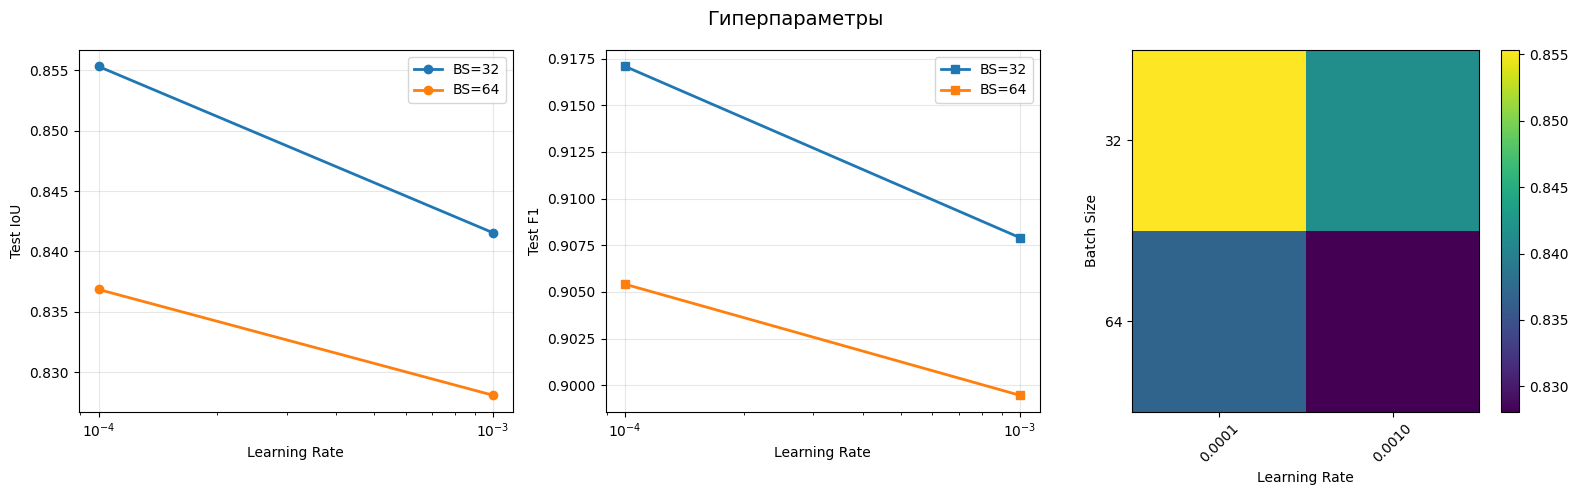

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Гиперпараметры', fontsize=14)

bs_results = {}
for key, data in hyperparams_results.items():
    bs = data['config'].batch_size
    if bs not in bs_results:
        bs_results[bs] = {'lrs': [], 'ious': [], 'f1s': []}
    bs_results[bs]['lrs'].append(data['config'].learning_rate)
    bs_results[bs]['ious'].append(data['test_iou'])
    bs_results[bs]['f1s'].append(data['test_f1'])

for bs in sorted(bs_results.keys()):
    lrs_sorted, ious_sorted = zip(*sorted(zip(bs_results[bs]['lrs'], bs_results[bs]['ious'])))
    axes[0].plot(lrs_sorted, ious_sorted, marker='o', label=f'BS={bs}', linewidth=2)
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Test IoU')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for bs in sorted(bs_results.keys()):
    lrs_sorted, f1s_sorted = zip(*sorted(zip(bs_results[bs]['lrs'], bs_results[bs]['f1s'])))
    axes[1].plot(lrs_sorted, f1s_sorted, marker='s', label=f'BS={bs}', linewidth=2)
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Test F1')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

learning_rates_list = [0.0001, 0.001]
batch_sizes_list = [32, 64]
iou_matrix = np.zeros((len(batch_sizes_list), len(learning_rates_list)))
for i, bs in enumerate(batch_sizes_list):
    for j, lr in enumerate(learning_rates_list):
        key = f"lr_{lr}_bs_{bs}"
        iou_matrix[i, j] = hyperparams_results[key]['test_iou']

im = axes[2].imshow(iou_matrix, cmap='viridis', aspect='auto')
axes[2].set_xticks(range(len(learning_rates_list)))
axes[2].set_yticks(range(len(batch_sizes_list)))
axes[2].set_xticklabels([f'{lr:.4f}' for lr in learning_rates_list], rotation=45)
axes[2].set_yticklabels([f'{bs}' for bs in batch_sizes_list])
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Batch Size')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150)
plt.show()

## Вывод

Результаты показывают тренд: меньшие learning rates и batch sizes дают более стабильное обучение. LR=0.0001, BS=32 показал лучший IoU=0.8553, в то время как более агрессивные настройки (LR=0.001) приводили к более шумистым метрикам валидации.

In [13]:
print("\n" + "="*70)
print("Обучение модификаций")
print("="*70)

best_config = Config()
best_config.epochs = 4
best_config.batch_size = 64
best_config.learning_rate = 0.0001

print("\nDeepUNet...")
deep_model = DeepUNet()
trainer_deep = Trainer(best_config, model=deep_model)
trainer_deep.run()

print("\nUNetWithDropout...")
dropout_model = UNetWithDropout()
trainer_dropout = Trainer(best_config, model=dropout_model)
trainer_dropout.run()

print("\nBase U-Net...")
base_model = UNet()
trainer_base_compare = Trainer(best_config, model=base_model)
trainer_base_compare.run()


Обучение модификаций

DeepUNet...


100%|██████████| 12/12 [00:13<00:00,  1.12s/it]


Epoch 1 / 4, Train Loss: 0.4966, Val Loss: 0.5144, Val IoU: 0.7677, Val F1-score: 0.8636


100%|██████████| 12/12 [00:13<00:00,  1.12s/it]


Epoch 2 / 4, Train Loss: 0.3608, Val Loss: 0.3372, Val IoU: 0.8351, Val F1-score: 0.9055


...

Epoch 3 / 4, Train Loss: 0.3265, Val Loss: 0.3113, Val IoU: 0.8411, Val F1-score: 0.9086


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 4 / 4, Train Loss: 0.2922, Val Loss: 0.2972, Val IoU: 0.8358, Val F1-score: 0.9057
Testing...


100%|██████████| 58/58 [01:04<00:00,  1.11s/it]

Test Loss: 0.2968, Test IoU: 0.8364, Test F1-score: 0.9052



Сравнение модификаций


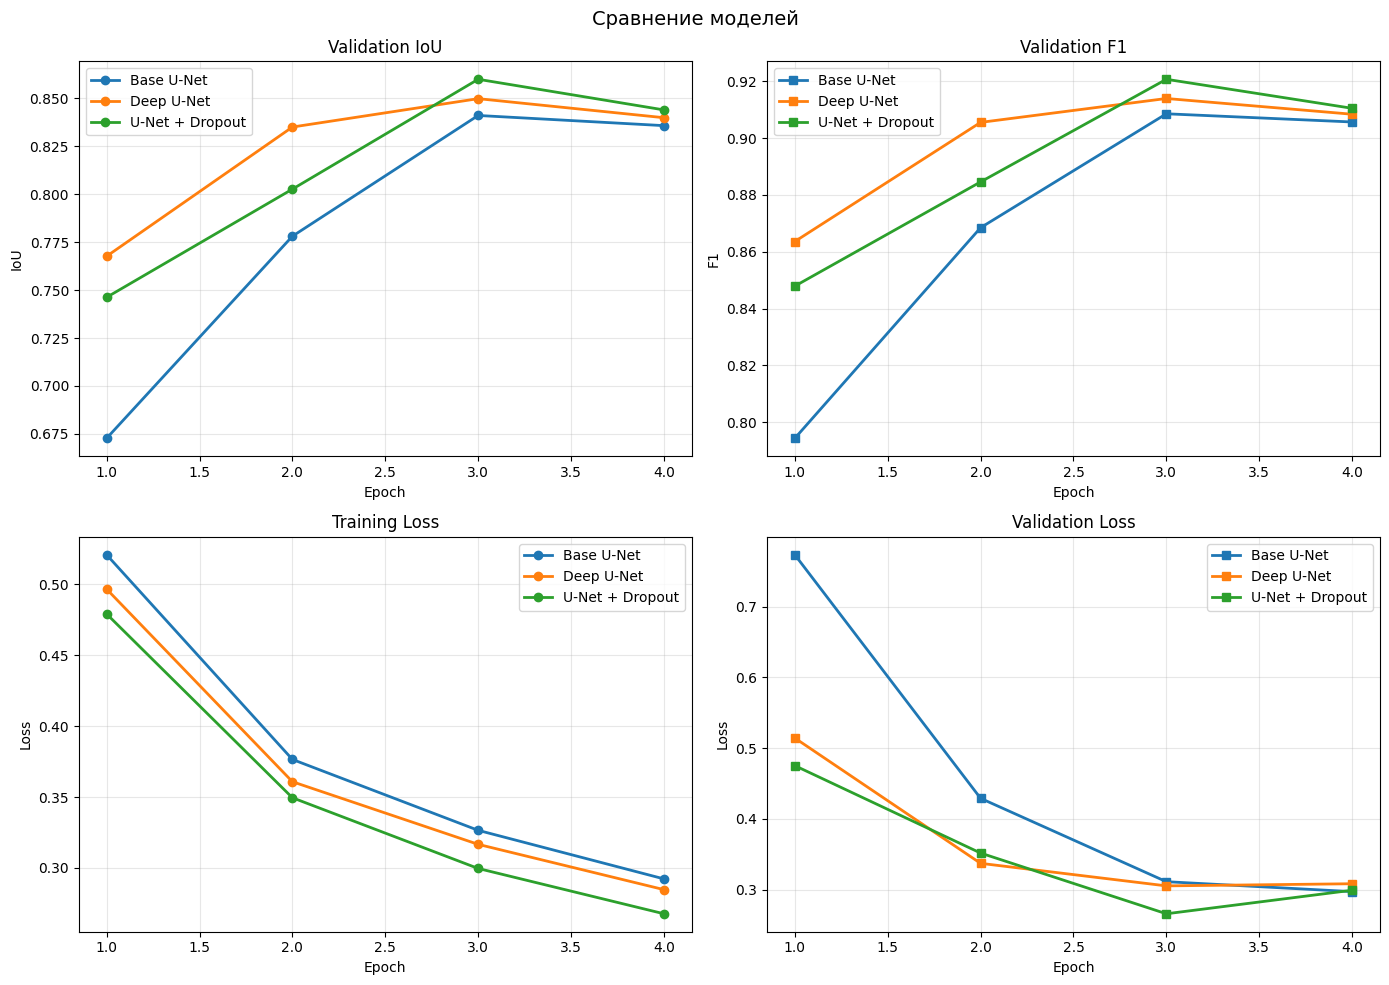


Тестовые результаты:
Model                     Loss         IoU          F1          
Base U-Net                0.2968       0.8364       0.9052      
Deep U-Net                0.3071       0.8376       0.9060      
U-Net + Dropout           0.3114       0.8342       0.9030      


In [14]:
print("\n" + "="*70)
print("Сравнение модификаций")
print("="*70)

models = {
    'Base U-Net': trainer_base_compare,
    'Deep U-Net': trainer_deep,
    'U-Net + Dropout': trainer_dropout
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей', fontsize=14)

epochs = range(1, best_config.epochs + 1)

for name, trainer in models.items():
    axes[0, 0].plot(epochs, trainer.history['val_iou'], marker='o', label=name, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('IoU')
axes[0, 0].set_title('Validation IoU')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for name, trainer in models.items():
    axes[0, 1].plot(epochs, trainer.history['val_f1'], marker='s', label=name, linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1')
axes[0, 1].set_title('Validation F1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for name, trainer in models.items():
    axes[1, 0].plot(epochs, trainer.history['train_loss'], marker='o', label=name, linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for name, trainer in models.items():
    axes[1, 1].plot(epochs, trainer.history['val_loss'], marker='s', label=name, linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Validation Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("\nТестовые результаты:")
print(f"{'Model':<25} {'Loss':<12} {'IoU':<12} {'F1':<12}")
for name, trainer in models.items():
    print(f"{name:<25} {trainer.history['test_loss']:<12.4f} {trainer.history['test_iou']:<12.4f} {trainer.history['test_f1']:<12.4f}")